In [1]:
# 2차 EDA를 위해 Netflix 콘텐츠 단위 데이터와 TMDB 메타데이터를 불러오기

import pandas as pd
import matplotlib.pyplot as plt
# 로그 변환에 사용할 NumPy 불러오기
import numpy as np

In [2]:
# 2차 EDA에 사용할 Netflix 분석 데이터와 TMDB 메타데이터 불러오기

import pandas as pd

netflix_tv_df = pd.read_csv(
    "../DATA/PROCESSED/netflix_tv_analysis.csv"
)

tmdb_df = pd.read_csv(
    "../DATA/PROCESSED/tmdb_metadata.csv"
)

print("Netflix:", netflix_tv_df.shape)
print("TMDB:", tmdb_df.shape)

Netflix: (159, 13)
TMDB: (402, 15)


In [3]:
# Netflix TV 분석 데이터와 TMDB 메타데이터를 작품명 기준으로 병합

merged_df = netflix_tv_df.merge(
    tmdb_df,
    left_on="show_title",
    right_on="netflix_title",
    how="left"
)

print(merged_df.shape)

(159, 28)


In [4]:
# 병합 후 TMDB 정보가 빠진 작품 수를 확인

print("TMDB 미매칭:", merged_df["tmdb_id"].isna().sum())

TMDB 미매칭: 0


In [5]:
# 같은 show_title이 여러 시즌으로 중복되어 있는지 확인

print("show_title 중복:", merged_df["show_title"].duplicated().sum())

show_title 중복: 28


In [6]:
# 같은 show_title이 여러 행에 나타나는 중복 작품들을 확인

duplicate_titles = merged_df[
    merged_df["show_title"].duplicated(keep=False)
].sort_values("show_title")

print(
    duplicate_titles[
        [
            "content_key",
            "show_title",
            "category",
            "max_cumulative",
            "long_hit",
            "first_rank",
            "first_week_hours"
        ]
    ].to_string(index=False)
)

                content_key        show_title         category  max_cumulative  long_hit  first_rank  first_week_hours
        CoComelon: Season 1         CoComelon     TV (English)               1         0          10           9140000
        CoComelon: Season 3         CoComelon     TV (English)               5         1           9          11430000
        CoComelon: Season 4         CoComelon     TV (English)               5         1           8          15930000
        Cobra Kai: Season 1         Cobra Kai     TV (English)               2         0           8          13450000
        Cobra Kai: Season 2         Cobra Kai     TV (English)               1         0          10          19340000
        Control Z: Season 1         Control Z TV (Non-English)               1         0           7           8580000
        Control Z: Season 2         Control Z TV (Non-English)               3         0           2          25430000
            Elite: Season 1             Elite TV

한 행 = Netflix 시즌/콘텐츠

Netflix 성과
long_hit
first_rank
first_week_hours
initial_country_reach
max_cumulative

+

TMDB 작품 특성
genres
original_language
production_countries
number_of_seasons
number_of_episodes
vote_average
...

In [7]:
# Netflix 시즌 데이터 중 TMDB 메타데이터가 연결되지 않은 행이 있는지 확인

print("TMDB 미매칭:", merged_df["tmdb_id"].isna().sum())

TMDB 미매칭: 0


In [8]:
# TMDB 정보가 매칭되지 않은 Netflix 작품을 확인

merged_df.loc[
    merged_df["tmdb_id"].isna(),
    ["content_key", "show_title", "category"]
]

,content_key,show_title,category


In [9]:
# 같은 show_title이 여러 시즌으로 존재하는 작품 수를 확인

duplicate_show_count = (
    merged_df.loc[
        merged_df["show_title"].duplicated(keep=False),
        "show_title"
    ]
    .nunique()
)

print("여러 시즌이 있는 작품 수:", duplicate_show_count)

여러 시즌이 있는 작품 수: 17


In [10]:
# Netflix + TMDB 병합 데이터의 컬럼별 결측치 개수를 확인

merged_df.isna().sum()

content_key                0
show_title                 0
category                   0
first_week                 0
last_week                  0
first_cumulative           0
max_cumulative             0
right_censored             0
long_hit                   0
first_rank                 0
first_week_hours           0
log_first_week_hours       0
initial_country_reach      1
netflix_title              0
tmdb_id                    0
tmdb_type                  0
genres                     0
original_language          0
production_countries       6
release_date             158
first_air_date             1
runtime                  158
episode_run_time           1
number_of_seasons          1
number_of_episodes         1
vote_average               0
vote_count                 0
popularity                 0
dtype: int64

In [11]:
# 병합된 최종 데이터의 크기와 컬럼을 확인

print("데이터 크기:", merged_df.shape)
print("\n컬럼:")
print(merged_df.columns.tolist())

데이터 크기: (159, 28)

컬럼:
['content_key', 'show_title', 'category', 'first_week', 'last_week', 'first_cumulative', 'max_cumulative', 'right_censored', 'long_hit', 'first_rank', 'first_week_hours', 'log_first_week_hours', 'initial_country_reach', 'netflix_title', 'tmdb_id', 'tmdb_type', 'genres', 'original_language', 'production_countries', 'release_date', 'first_air_date', 'runtime', 'episode_run_time', 'number_of_seasons', 'number_of_episodes', 'vote_average', 'vote_count', 'popularity']


1. release_date 158, runtime 158은 정상

사용하는 Netflix 데이터 159개는 기본적으로 TV 콘텐츠이나, 앞에서 예외로 하나 존재.

Dave Chappelle: The Closer
Netflix → TV (English)
TMDB → movie

그래서 최종적으로는:

TV    158개
movie   1개

형태일 가능성이 높음.

따라서:

release_date 결측 158개
runtime 결측 158개

영화 1개에만 값이 있어서 생긴 정상적인 구조적 결측.

반대로:

first_air_date 결측 1
number_of_seasons 결측 1
number_of_episodes 결측 1

도 바로 그 movie 1개 때문일 가능성이 높다.

In [12]:
# 병합 데이터에서 TMDB 기준 movie와 tv 작품 수를 확인

merged_df["tmdb_type"].value_counts()

tmdb_type
tv       158
movie      1
Name: count, dtype: int64

### TMDB 최초 공개일 기준 오매칭 후보 검토

Netflix 데이터 관측 종료일(`2022-01-16`)보다 `first_air_date`가 늦은 TV 매칭 9개 행(7개 작품)을 대상으로 Search API 후보를 다시 비교한다. 검토 단계에서는 `merged_df`를 수정하지 않는다.

In [13]:
# 초기 국가 도달 수가 누락된 Netflix 콘텐츠를 확인

merged_df.loc[
    merged_df["initial_country_reach"].isna(),
    ["content_key", "show_title", "category", "first_week"]
]

,content_key,show_title,category,first_week
97,Octonauts: Above & Beyond: Season 1,Octonauts: Above & Beyond,TV (English),2021-09-12


In [14]:
# 초기 국가 도달 수 누락 원인을 확인하기 위해 Netflix 국가별 원본 데이터를 불러오기

country_df = pd.read_csv(
    "../DATA/RAW/[엔터] Netflix Top 10 Weekly Dataset/all-weeks-countries.csv",
    encoding="latin1"
)

In [15]:
# 초기 국가 도달 수가 누락된 작품이 국가별 Netflix 데이터에 존재하는지 확인

octonauts_country = country_df[
    country_df["show_title"] == "Octonauts: Above & Beyond"
]

print(octonauts_country.shape)
print(octonauts_country.head(20).to_string(index=False))

(0, 8)
Empty DataFrame
Columns: [country_name, country_iso2, week, category, weekly_rank, show_title, season_title, cumulative_weeks_in_top_10]
Index: []


In [16]:
# 국가별 Netflix 데이터에 Octonauts 관련 작품이 다른 제목으로 저장되어 있는지 확인

octonauts_candidates = country_df[
    country_df["show_title"].str.contains(
        "Octonauts",
        case=False,
        na=False
    )
]

print(octonauts_candidates.shape)

print(
    octonauts_candidates[
        ["show_title", "season_title", "category"]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

(0, 8)
Empty DataFrame
Columns: [show_title, season_title, category]
Index: []


Octonauts: Above & Beyond는 국가별 Netflix 데이터에 아예 존재하지 않아서 initial_country_reach를 계산할 수 없는 것.

그래서 이 값은:

0이 아님
→ 데이터 없음
→ NaN 유지

로 처리

In [17]:
# TMDB 제작국가 정보가 없는 작품 6개를 확인

missing_production_country = merged_df.loc[
    merged_df["production_countries"].isna(),
    ["show_title", "tmdb_id", "tmdb_type", "genres", "original_language"]
]

print(missing_production_country.to_string(index=False))

                                     show_title  tmdb_id tmdb_type                genres original_language
            Cocaine Cowboys: The Kings of Miami   129206        tv           Documentary                en
                                      Dive Club   131830        tv                 Drama                en
                                          Elves    70059        tv       Animation, Kids                en
                                  Gone for Good   128068        tv Crime, Drama, Mystery                fr
Monsters Inside: The 24 Faces of Billy Milligan   132105        tv    Documentary, Crime                en
          Top Secret UFO Projects: Declassified   129677        tv           Documentary                en


In [18]:
# TV 작품의 episode_run_time에서 빈 리스트("[]")로 저장된 작품 수를 확인

empty_runtime_count = (
    merged_df["episode_run_time"]
    .astype(str)
    .eq("[]")
    .sum()
)

print("episode_run_time 빈 리스트:", empty_runtime_count)

episode_run_time 빈 리스트: 77


### episode_run_time 데이터 품질 확인

TMDB의 TV 상세정보에서 `episode_run_time`이 빈 리스트(`[]`)로 제공되는 사례가 다수 확인되었다.

- 분석 대상 TV 콘텐츠: 158개
- 빈 리스트: 77개
- 약 49%의 러닝타임 정보가 부족함

따라서 `episode_run_time`은 핵심 EDA 변수에서 우선 제외하고,
필요 시 보조 분석 변수로만 활용한다.

In [19]:
# 프로젝트 .env에서 TMDB API 키를 안전하게 불러오기

import os
from pathlib import Path

import requests
from dotenv import load_dotenv

env_path = Path("../.env") if Path("../.env").exists() else Path(".env")
load_dotenv(dotenv_path=env_path, override=False)
TMDB_API_KEY = os.getenv("TMDB_API_KEY")

if not TMDB_API_KEY:
    raise EnvironmentError(".env에서 TMDB_API_KEY를 찾을 수 없습니다.")
# TMDB TV 검색과 상세정보 조회에 재사용할 함수 정의

def search_tmdb(title, tmdb_type="tv"):
    url = f"https://api.themoviedb.org/3/search/{tmdb_type}"
    params = {
        "api_key": TMDB_API_KEY,
        "query": title,
        "language": "en-US",
        "include_adult": False
    }
    response = requests.get(url, params=params, timeout=15)
    response.raise_for_status()
    return response.json().get("results", [])

def get_tmdb_details(tmdb_id, tmdb_type="tv"):
    url = f"https://api.themoviedb.org/3/{tmdb_type}/{int(tmdb_id)}"
    params = {"api_key": TMDB_API_KEY, "language": "en-US"}
    response = requests.get(url, params=params, timeout=15)
    response.raise_for_status()
    return response.json()
# 오매칭 후보 7개를 TV 타입으로 재검색하고 제목·원제·언어·공개일 검토표 생성

netflix_observation_end = pd.Timestamp("2022-01-16")
mismatch_target_titles = [
    "CoComelon", "Love Never Lies", "Newly Rich, Newly Poor",
    "The Chair", "The Club", "The Seven Deadly Sins",
    "The Snitch Cartel: Origins"
]
recommended_tmdb_ids = {
    "CoComelon": 114718,
    "Love Never Lies": 138400,
    "Newly Rich, Newly Poor": 7311,
    "The Chair": 99657,
    "The Club": 95467,
    "The Seven Deadly Sins": 62104,
    "The Snitch Cartel: Origins": 128252,
}

parsed_first_air_date = pd.to_datetime(merged_df["first_air_date"], errors="coerce")
tmdb_mismatch_rows = merged_df.loc[
    merged_df["tmdb_type"].eq("tv")
    & parsed_first_air_date.gt(netflix_observation_end)
    & merged_df["show_title"].isin(mismatch_target_titles),
    ["content_key", "show_title", "tmdb_id", "original_language", "first_air_date"]
].copy()
current_matches = (
    tmdb_mismatch_rows.drop_duplicates("show_title")
    .set_index("show_title")
)

candidate_rows = []
for netflix_title in mismatch_target_titles:
    for search_rank, result in enumerate(search_tmdb(netflix_title, "tv"), start=1):
        candidate_date = pd.to_datetime(result.get("first_air_date"), errors="coerce")
        candidate_id = result.get("id")
        candidate_rows.append({
            "netflix_title": netflix_title,
            "search_rank": search_rank,
            "candidate_tmdb_id": candidate_id,
            "candidate_title": result.get("name"),
            "candidate_original_title": result.get("original_name"),
            "candidate_language": result.get("original_language"),
            "candidate_first_air_date": result.get("first_air_date"),
            "origin_country": ", ".join(result.get("origin_country", [])),
            "within_observation_period": pd.notna(candidate_date) and candidate_date <= netflix_observation_end,
            "is_current_match": candidate_id == current_matches.loc[netflix_title, "tmdb_id"],
            "is_recommended": candidate_id == recommended_tmdb_ids[netflix_title],
        })

tmdb_search_candidates_df = pd.DataFrame(candidate_rows)
tmdb_candidate_review_df = (
    tmdb_search_candidates_df.loc[
        tmdb_search_candidates_df["within_observation_period"]
        | tmdb_search_candidates_df["is_current_match"]
        | tmdb_search_candidates_df["is_recommended"]
    ]
    .sort_values(
        ["netflix_title", "is_recommended", "within_observation_period", "search_rank"],
        ascending=[True, False, False, True]
    )
    .reset_index(drop=True)
)

tmdb_recommendation_df = tmdb_candidate_review_df.loc[
    tmdb_candidate_review_df["is_recommended"],
    [
        "netflix_title", "candidate_tmdb_id", "candidate_title",
        "candidate_original_title", "candidate_language",
        "candidate_first_air_date", "within_observation_period"
    ]
].copy()
tmdb_recommendation_df["decision"] = tmdb_recommendation_df["within_observation_period"].map(
    {True: "교체 제안", False: "보류: 종료일 이전 후보 없음"}
)

print("검토 대상 행 수:", len(tmdb_mismatch_rows))
display(tmdb_mismatch_rows.sort_values(["show_title", "content_key"]))
display(tmdb_candidate_review_df)
display(tmdb_recommendation_df)
# 검토가 끝난 후보만 명시적으로 승인한 뒤 merged_df의 TMDB 메타데이터 보정

APPLY_CONFIRMED_CORRECTIONS = False
confirmed_tmdb_corrections = {
    "CoComelon": 114718,
    "Love Never Lies": 138400,
    "Newly Rich, Newly Poor": 7311,
    "The Chair": 99657,
    "The Club": 95467,
    "The Seven Deadly Sins": 62104,
    # The Snitch Cartel: Origins는 종료일 이전 후보가 없어 보류
}

if APPLY_CONFIRMED_CORRECTIONS:
    for netflix_title, tmdb_id in confirmed_tmdb_corrections.items():
        detail = get_tmdb_details(tmdb_id, "tv")
        corrected_values = {
            "tmdb_id": tmdb_id,
            "tmdb_type": "tv",
            "genres": ", ".join(genre["name"] for genre in detail.get("genres", [])),
            "original_language": detail.get("original_language"),
            "production_countries": ", ".join(
                country["iso_3166_1"] for country in detail.get("production_countries", [])
            ),
            "release_date": detail.get("release_date"),
            "first_air_date": detail.get("first_air_date"),
            "runtime": detail.get("runtime"),
            "episode_run_time": detail.get("episode_run_time"),
            "number_of_seasons": detail.get("number_of_seasons"),
            "number_of_episodes": detail.get("number_of_episodes"),
            "vote_average": detail.get("vote_average"),
            "vote_count": detail.get("vote_count"),
            "popularity": detail.get("popularity"),
        }
        for target_index in merged_df.index[merged_df["show_title"].eq(netflix_title)]:
            for column, value in corrected_values.items():
                merged_df.at[target_index, column] = value

    print("보정 완료 작품 수:", len(confirmed_tmdb_corrections))
else:
    print("검토 모드: merged_df는 변경되지 않았습니다.")
# The Club의 TMDB 후보를 다시 검색하고 터키어/공개일 정보를 중심으로 확인

the_club_candidates = search_tmdb("The Club", "tv")

for result in the_club_candidates[:20]:
    print("제목:", result.get("name"))
    print("원제:", result.get("original_name"))
    print("언어:", result.get("original_language"))
    print("국가:", result.get("origin_country"))
    print("공개일:", result.get("first_air_date"))
    print("TMDB ID:", result.get("id"))
    print("-" * 50)
# The Club의 터키 원제인 Kulüp으로 TMDB 후보를 다시 검색

the_club_turkish = search_tmdb("Kulüp", "tv")

for result in the_club_turkish[:10]:
    print("제목:", result.get("name"))
    print("원제:", result.get("original_name"))
    print("언어:", result.get("original_language"))
    print("국가:", result.get("origin_country"))
    print("공개일:", result.get("first_air_date"))
    print("TMDB ID:", result.get("id"))
    print("-" * 50)
# 최종 검토가 끝난 작품만 TMDB 보정 대상으로 확정

confirmed_tmdb_corrections = {
    "CoComelon": 114718,
    "Love Never Lies": 138400,
    "Newly Rich, Newly Poor": 7311,
    "The Chair": 99657,
    "The Club": 136125,
    "The Seven Deadly Sins": 62104,
}
# 보정 도중 일부 값만 변경되었을 가능성이 있어 Netflix와 TMDB 원본 병합을 다시 수행

merged_df = netflix_tv_df.merge(
    tmdb_df,
    left_on="show_title",
    right_on="netflix_title",
    how="left"
)

print(merged_df.shape)
# TMDB 보정에 사용하는 주요 컬럼의 현재 자료형을 확인

columns_to_check = [
    "tmdb_id",
    "genres",
    "original_language",
    "production_countries",
    "first_air_date",
    "episode_run_time",
    "number_of_seasons",
    "number_of_episodes",
    "vote_average",
    "vote_count",
    "popularity"
]

print(merged_df[columns_to_check].dtypes)

# 검토가 완료된 6개 작품의 TMDB 메타데이터를 merged_df에 최종 반영

confirmed_tmdb_corrections = {
    "CoComelon": 114718,
    "Love Never Lies": 138400,
    "Newly Rich, Newly Poor": 7311,
    "The Chair": 99657,
    "The Club": 136125,
    "The Seven Deadly Sins": 62104,
}

for netflix_title, tmdb_id in confirmed_tmdb_corrections.items():

    detail = get_tmdb_details(tmdb_id, "tv")

    corrected_values = {
        "tmdb_id": tmdb_id,
        "tmdb_type": "tv",
        "genres": ", ".join(
            genre["name"] for genre in detail.get("genres", [])
        ),
        "original_language": detail.get("original_language"),
        "production_countries": ", ".join(
            country["iso_3166_1"]
            for country in detail.get("production_countries", [])
        ),
        "release_date": detail.get("release_date"),
        "first_air_date": detail.get("first_air_date"),
        "runtime": detail.get("runtime"),
        "episode_run_time": str(detail.get("episode_run_time", [])),
        "number_of_seasons": detail.get("number_of_seasons"),
        "number_of_episodes": detail.get("number_of_episodes"),
        "vote_average": detail.get("vote_average"),
        "vote_count": detail.get("vote_count"),
        "popularity": detail.get("popularity"),
    }

    for column, value in corrected_values.items():
        merged_df.loc[
            merged_df["show_title"] == netflix_title,
            column
        ] = value

print("보정 완료 작품 수:", len(confirmed_tmdb_corrections))
# 보정된 6개 작품의 TMDB ID와 핵심 정보를 확인

correction_check = (
    merged_df.loc[
        merged_df["show_title"].isin(confirmed_tmdb_corrections.keys()),
        [
            "show_title",
            "tmdb_id",
            "original_language",
            "production_countries",
            "first_air_date",
            "genres"
        ]
    ]
    .drop_duplicates()
)

print(correction_check.to_string(index=False))
# 보정 후 Netflix 관측 종료일보다 늦은 TMDB 공개일이 남아 있는지 다시 확인

merged_df["first_air_date_dt"] = pd.to_datetime(
    merged_df["first_air_date"],
    errors="coerce"
)

remaining_invalid = merged_df[
    merged_df["first_air_date_dt"] > pd.Timestamp("2022-01-16")
][
    ["content_key", "show_title", "tmdb_id", "first_air_date"]
]

print("남은 검토 대상:", len(remaining_invalid))
print(remaining_invalid.to_string(index=False))
# 날짜 검증 예외 작품을 별도로 기록

date_validation_note = {
    "show_title": "The Snitch Cartel: Origins",
    "tmdb_id": 128252,
    "reason": "TMDB first_air_date가 Netflix 관측 종료일보다 늦지만, 작품 ID 자체는 유효한 것으로 판단하여 유지"
}

date_validation_note

검토 대상 행 수: 9


,content_key,show_title,tmdb_id,original_language,first_air_date
19,CoComelon: Season 1,CoComelon,209710,en,2023-11-17
20,CoComelon: Season 3,CoComelon,209710,en,2023-11-17
21,CoComelon: Season 4,CoComelon,209710,en,2023-11-17
74,Love Never Lies: Season 1,Love Never Lies,217309,pl,2023-01-25
96,"Newly Rich, Newly Poor: Season 1","Newly Rich, Newly Poor",283917,es,2025-02-10
124,The Chair: Season 1,The Chair,271267,en,2025-10-12
127,The Club: Part 1,The Club,286822,it,2025-10-01
135,The Seven Deadly Sins: Dragon's Judgement,The Seven Deadly Sins,218843,ja,2023-10-08
137,The Snitch Cartel: Origins: Season 1,The Snitch Cartel: Origins,128252,es,2022-06-14


,netflix_title,search_rank,candidate_tmdb_id,candidate_title,candidate_original_title,candidate_language,candidate_first_air_date,origin_country,within_observation_period,is_current_match,is_recommended
0,CoComelon,2,114718,Cocomelon,Cocomelon,en,2020-05-31,"US, GB",True,False,True
1,CoComelon,3,133128,CoComelon Stories,CoComelon Stories,en,2021-06-18,,True,False,False
2,CoComelon,1,209710,CoComelon Lane,CoComelon Lane,en,2023-11-17,US,False,True,False
3,Love Never Lies,2,138400,Love Never Lies,Amor con fianza,es,2021-11-11,ES,True,False,True
4,Love Never Lies,1,217309,Love Never Lies: Poland,Love Never Lies: Polska,pl,2023-01-25,PL,False,True,False
5,"Newly Rich, Newly Poor",2,7311,Nuevo Rico Nuevo Pobre,Nuevo Rico Nuevo Pobre,es,2007-07-16,CO,True,False,True
6,"Newly Rich, Newly Poor",1,283917,"Newly Rich, Newly Poor","Nuevo Rico, Nuevo Pobre",es,2025-02-10,CO,False,True,False
7,The Chair,2,99657,The Chair,The Chair,en,2021-08-20,US,True,False,True
8,The Chair,3,61566,The Chair,The Chair,en,2014-09-06,US,True,False,False
9,The Chair,4,22193,The Chair,The Chair,en,2002-08-31,GB,True,False,False


,netflix_title,candidate_tmdb_id,candidate_title,candidate_original_title,candidate_language,candidate_first_air_date,within_observation_period,decision
0,CoComelon,114718,Cocomelon,Cocomelon,en,2020-05-31,True,교체 제안
3,Love Never Lies,138400,Love Never Lies,Amor con fianza,es,2021-11-11,True,교체 제안
5,"Newly Rich, Newly Poor",7311,Nuevo Rico Nuevo Pobre,Nuevo Rico Nuevo Pobre,es,2007-07-16,True,교체 제안
7,The Chair,99657,The Chair,The Chair,en,2021-08-20,True,교체 제안
16,The Club,95467,The Club,El Club,es,2019-11-15,True,교체 제안
29,The Seven Deadly Sins,62104,The Seven Deadly Sins,七つの大罪,ja,2014-10-05,True,교체 제안
34,The Snitch Cartel: Origins,128252,The Snitch Cartel: Origins,El cartel de los sapos: El origen,es,2022-06-14,False,보류: 종료일 이전 후보 없음


검토 모드: merged_df는 변경되지 않았습니다.
제목: Winx Club: The Magic Is Back
원제: Winx Club: The Magic Is Back
언어: it
국가: ['IT']
공개일: 2025-10-01
TMDB ID: 286822
--------------------------------------------------
제목: The Marlow Murder Club
원제: The Marlow Murder Club
언어: en
국가: ['GB']
공개일: 2024-03-06
TMDB ID: 228079
--------------------------------------------------
제목: The Baby-Sitters Club
원제: The Baby-Sitters Club
언어: en
국가: ['US']
공개일: 2020-07-03
TMDB ID: 100412
--------------------------------------------------
제목: The Midnight Club
원제: The Midnight Club
언어: en
국가: ['US']
공개일: 2022-10-07
TMDB ID: 126254
--------------------------------------------------
제목: The Astronaut Wives Club
원제: The Astronaut Wives Club
언어: en
국가: ['US']
공개일: 2015-06-18
TMDB ID: 62458
--------------------------------------------------
제목: The Paradise Club
원제: The Paradise Club
언어: en
국가: ['GB']
공개일: 1989-09-19
TMDB ID: 31401
--------------------------------------------------
제목: The Saddle Club
원제: The Saddle Club
언어: en
국

{'show_title': 'The Snitch Cartel: Origins',
 'tmdb_id': 128252,
 'reason': 'TMDB first_air_date가 Netflix 관측 종료일보다 늦지만, 작품 ID 자체는 유효한 것으로 판단하여 유지'}

In [20]:
# 장르 문자열을 개별 장르 리스트로 분리한 뒤 한 장르씩 행으로 펼치기

genre_df = merged_df.copy()

genre_df["genre"] = genre_df["genres"].str.split(", ")

genre_df = genre_df.explode("genre")

print(genre_df[["show_title", "genres", "genre", "long_hit"]].head(10).to_string(index=False))

               show_title                                              genres              genre  long_hit
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family               Kids         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family Action & Adventure         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family          Animation         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family             Comedy         0
      A Tale Dark & Grimm Kids, Action & Adventure, Animation, Comedy, Family             Family         0
AlRawabi School for Girls                                               Drama              Drama         0
      Alice in Borderland                  Mystery, Drama, Action & Adventure            Mystery         1
      Alice in Borderland                  Mystery, Drama, Action & Adventure              Drama         1
      Alice in Borderland            

In [21]:
# 장르별 콘텐츠 수와 장기흥행 비율을 계산

genre_long_hit = (
    genre_df.groupby("genre")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

genre_long_hit

,content_count,long_hit_count,long_hit_rate
genre,,,
Soap,3,3,1.000000
Mystery,30,14,0.466667
Crime,42,17,0.404762
Drama,89,33,0.370787
Action & Adventure,29,6,0.206897
Sci-Fi & Fantasy,37,7,0.189189
Comedy,43,8,0.186047
Animation,26,4,0.153846
Kids,13,2,0.153846


In [22]:
# 콘텐츠 수가 10개 이상인 장르만 남겨 장기흥행 비율을 비교

genre_long_hit_filtered = genre_long_hit[
    genre_long_hit["content_count"] >= 10
].sort_values("long_hit_rate", ascending=False)

genre_long_hit_filtered

,content_count,long_hit_count,long_hit_rate
genre,,,
Mystery,30,14,0.466667
Crime,42,17,0.404762
Drama,89,33,0.370787
Action & Adventure,29,6,0.206897
Sci-Fi & Fantasy,37,7,0.189189
Comedy,43,8,0.186047
Animation,26,4,0.153846
Kids,13,2,0.153846
Family,12,1,0.083333


In [23]:
# 장기흥행 비율을 퍼센트로 변환해 보기 쉽게 정리

genre_long_hit_filtered = genre_long_hit_filtered.copy()

genre_long_hit_filtered["long_hit_rate_pct"] = (
    genre_long_hit_filtered["long_hit_rate"] * 100
).round(1)

genre_long_hit_filtered

,content_count,long_hit_count,long_hit_rate,long_hit_rate_pct
genre,,,,
Mystery,30,14,0.466667,46.7
Crime,42,17,0.404762,40.5
Drama,89,33,0.370787,37.1
Action & Adventure,29,6,0.206897,20.7
Sci-Fi & Fantasy,37,7,0.189189,18.9
Comedy,43,8,0.186047,18.6
Animation,26,4,0.153846,15.4
Kids,13,2,0.153846,15.4
Family,12,1,0.083333,8.3


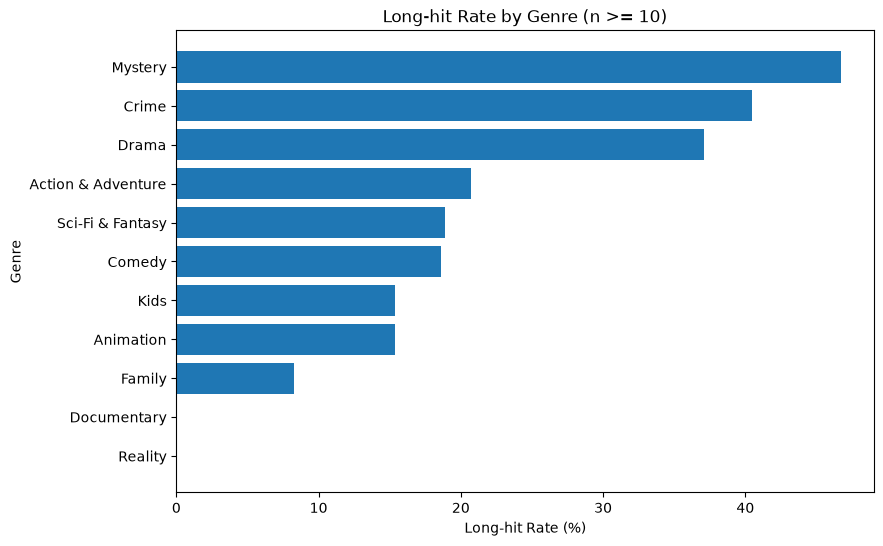

In [24]:
# 표본 10개 이상 장르의 장기흥행 비율을 막대그래프로 시각화

plot_data = genre_long_hit_filtered.sort_values(
    "long_hit_rate_pct",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data.index,
    plot_data["long_hit_rate_pct"]
)

plt.xlabel("Long-hit Rate (%)")
plt.ylabel("Genre")
plt.title("Long-hit Rate by Genre (n >= 10)")

plt.show()

### 장르별 장기흥행 비율

표본 수가 10개 이상인 장르를 기준으로 비교한 결과,
Mystery가 46.67%로 가장 높은 장기흥행 비율을 보였고,
Crime 40.48%, Drama 37.08%가 그 뒤를 이었다.

반면 Animation과 Kids는 각각 15.38%로 상대적으로 낮았으며,
Documentary와 Reality에서는 이번 분석 기간 내 장기흥행 사례가 확인되지 않았다.

다만 하나의 작품이 여러 장르에 동시에 포함될 수 있으므로,
이 결과를 특정 장르가 장기흥행을 직접적으로 만든다고 해석하기보다는
해당 장르 특성을 가진 콘텐츠에서 관찰된 장기흥행 경향으로 해석한다.

In [25]:
# Animation 장르가 포함된 작품만 추출해 장기흥행 여부와 장르 조합을 확인

animation_df = merged_df[
    merged_df["genres"].str.contains("Animation", na=False)
].copy()

print(animation_df.shape)

print(
    animation_df[
        [
            "show_title",
            "genres",
            "long_hit",
            "max_cumulative",
            "first_rank",
            "first_week_hours"
        ]
    ]
    .sort_values(
        ["long_hit", "max_cumulative"],
        ascending=[False, False]
    )
    .to_string(index=False)
)

(26, 29)
                    show_title                                                          genres  long_hit  max_cumulative  first_rank  first_week_hours
                        Arcane                 Animation, Action & Adventure, Sci-Fi & Fantasy         1               6           2          34170000
                     CoComelon                                                 Animation, Kids         1               5           9          11430000
                     CoComelon                                                 Animation, Kids         1               5           8          15930000
         The Seven Deadly Sins                 Animation, Action & Adventure, Sci-Fi & Fantasy         1               4           2          33240000
                     Big Mouth                                               Comedy, Animation         0               3           9          19570000
                  Cowboy Bebop        Animation, Action & Adventure, Sci-Fi & Fantasy

장르만으로는 설명 부족
↓
평점?
투표 수?
시즌/에피소드 수?
언어?
제작 국가?
초기 Netflix 성과?

애니메이션 콘텐츠 전체의 장기흥행 비율은 낮았지만, 장기흥행 사례 중에서는 Action & Adventure와 Sci-Fi & Fantasy가 결합된 작품이 일부 확인되었다.

In [26]:
# Animation 콘텐츠의 장기흥행 여부별 개수와 비율을 확인

animation_long_hit = animation_df["long_hit"].value_counts().sort_index()

print(animation_long_hit)

print(
    "\n장기흥행 비율:",
    round(animation_df["long_hit"].mean() * 100, 1),
    "%"
)

long_hit
0    22
1     4
Name: count, dtype: int64

장기흥행 비율: 15.4 %


In [27]:
# Animation 작품에서 Animation을 제외한 보조 장르별 등장 횟수와 장기흥행 횟수를 확인

animation_genre_df = animation_df.copy()

animation_genre_df["sub_genre"] = animation_genre_df["genres"].str.split(", ")
animation_genre_df = animation_genre_df.explode("sub_genre")

animation_genre_df = animation_genre_df[
    animation_genre_df["sub_genre"] != "Animation"
]

animation_subgenre = (
    animation_genre_df.groupby("sub_genre")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

animation_subgenre

,content_count,long_hit_count,long_hit_rate
sub_genre,,,
Kids,11,2,0.181818
Sci-Fi & Fantasy,14,2,0.142857
Action & Adventure,16,2,0.125000
Comedy,10,0,0.000000
Family,7,0,0.000000
Western,1,0,0.000000


### Animation 세부 장르 확인

Animation이 포함된 콘텐츠는 총 26개였으며,
이 중 장기흥행 콘텐츠는 4개로 장기흥행 비율은 15.38%였다.

Animation 콘텐츠의 보조 장르를 함께 확인한 결과,
Kids, Sci-Fi & Fantasy, Action & Adventure 등이 결합된 사례에서
일부 장기흥행 콘텐츠가 확인되었다.

다만 Animation 전체 표본과 장기흥행 사례 수가 많지 않기 때문에
세부 장르별 차이를 일반화하기보다는 탐색적 결과로 해석한다.

또한 동일하거나 유사한 장르 조합에서도 장기흥행 여부가 달라지는 사례가 있어,
장르 외에 초기 시청 성과, 국가 확산 범위, 작품 평가 등 다른 변수와 함께 확인할 필요가 있다.

In [28]:
# 원어별 콘텐츠 수와 장기흥행 비율을 계산

language_long_hit = (
    merged_df.groupby("original_language")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

language_long_hit

,content_count,long_hit_count,long_hit_rate
original_language,,,
da,1,1,1.000000
ko,8,5,0.625000
es,26,9,0.346154
en,89,25,0.280899
ja,11,2,0.181818
fr,6,1,0.166667
pt,6,1,0.166667
hi,2,0,0.000000
de,3,0,0.000000


In [29]:
# 원어별 콘텐츠 수를 확인

merged_df["original_language"].value_counts()

original_language
en    89
es    26
ja    11
ko     8
pt     6
fr     6
de     3
hi     2
tr     2
ar     1
is     1
pl     1
da     1
no     1
sv     1
Name: count, dtype: int64

In [30]:
# 콘텐츠가 5개 이상인 언어만 남겨 장기흥행 비율을 비교

language_long_hit_filtered = language_long_hit[
    language_long_hit["content_count"] >= 5
].copy()

language_long_hit_filtered["long_hit_rate_pct"] = (
    language_long_hit_filtered["long_hit_rate"] * 100
).round(1)

language_long_hit_filtered

,content_count,long_hit_count,long_hit_rate,long_hit_rate_pct
original_language,,,,
ko,8,5,0.625000,62.5
es,26,9,0.346154,34.6
en,89,25,0.280899,28.1
ja,11,2,0.181818,18.2
fr,6,1,0.166667,16.7
pt,6,1,0.166667,16.7


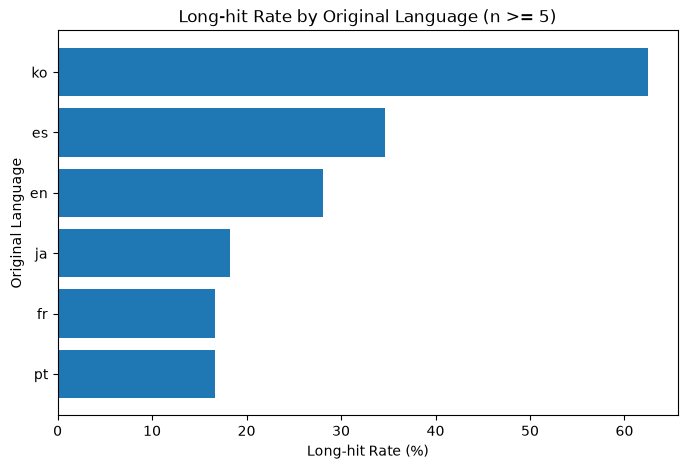

In [31]:
# 표본 5개 이상 언어의 장기흥행 비율을 막대그래프로 시각화

plot_data = language_long_hit_filtered.sort_values(
    "long_hit_rate_pct",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data.index,
    plot_data["long_hit_rate_pct"]
)

plt.xlabel("Long-hit Rate (%)")
plt.ylabel("Original Language")
plt.title("Long-hit Rate by Original Language (n >= 5)")

plt.show()

### 원어별 장기흥행 비율

표본 수가 5개 이상인 언어를 기준으로 비교한 결과,
한국어(ko) 콘텐츠가 8개 중 5개 장기흥행으로 62.50%의 가장 높은 비율을 보였다.

스페인어(es)는 34.62%, 영어(en)는 28.09%였으며,
일본어(ja)는 18.18%, 프랑스어(fr)와 포르투갈어(pt)는 각각 16.67%였다.

다만 한국어 콘텐츠의 표본 수는 8개로 적기 때문에
한국어 자체가 장기흥행에 유리하다고 일반화하기는 어렵다.

따라서 언어는 장르, 제작국가, 초기 국가 확산 범위 등과 함께
장기흥행 콘텐츠의 특성을 탐색하는 보조 변수로 해석한다.

In [32]:
# 제작국가 문자열을 개별 국가로 분리한 뒤 한 국가씩 행으로 펼치기

country_genre_df = merged_df.copy()

country_genre_df["production_country"] = (
    country_genre_df["production_countries"]
    .str.split(", ")
)

country_genre_df = country_genre_df.explode("production_country")

country_genre_df[
    ["show_title", "production_countries", "production_country", "long_hit"]
].head(10)

,show_title,production_countries,production_country,long_hit
0,A Tale Dark & Grimm,"CA, US",CA,0
0,A Tale Dark & Grimm,"CA, US",US,0
1,AlRawabi School for Girls,JO,JO,0
2,Alice in Borderland,JP,JP,1
3,All American,US,US,1
4,Another Life,CA,CA,0
5,Aranyak,IN,IN,0
6,Arcane,"FR, US",FR,1
6,Arcane,"FR, US",US,1
7,Atypical,US,US,0


In [33]:
# 제작국가별 콘텐츠 수와 장기흥행 비율을 계산

country_long_hit = (
    country_genre_df
    .dropna(subset=["production_country"])
    .groupby("production_country")
    .agg(
        content_count=("long_hit", "count"),
        long_hit_count=("long_hit", "sum"),
        long_hit_rate=("long_hit", "mean")
    )
    .sort_values("long_hit_rate", ascending=False)
)

country_long_hit

,content_count,long_hit_count,long_hit_rate
production_country,,,
AU,1,1,1.000000
CO,4,4,1.000000
DK,1,1,1.000000
IL,1,1,1.000000
KR,8,5,0.625000
FR,5,2,0.400000
GB,9,3,0.333333
US,78,26,0.333333
ES,15,4,0.266667


In [34]:
# 콘텐츠가 5개 이상인 제작국가만 남겨 장기흥행 비율을 비교

country_long_hit_filtered = country_long_hit[
    country_long_hit["content_count"] >= 5
].copy()

country_long_hit_filtered["long_hit_rate_pct"] = (
    country_long_hit_filtered["long_hit_rate"] * 100
).round(1)

country_long_hit_filtered

,content_count,long_hit_count,long_hit_rate,long_hit_rate_pct
production_country,,,,
KR,8,5,0.625000,62.5
FR,5,2,0.400000,40.0
GB,9,3,0.333333,33.3
US,78,26,0.333333,33.3
ES,15,4,0.266667,26.7
BR,5,1,0.200000,20.0
JP,11,2,0.181818,18.2
MX,8,1,0.125000,12.5
CA,5,0,0.000000,0.0


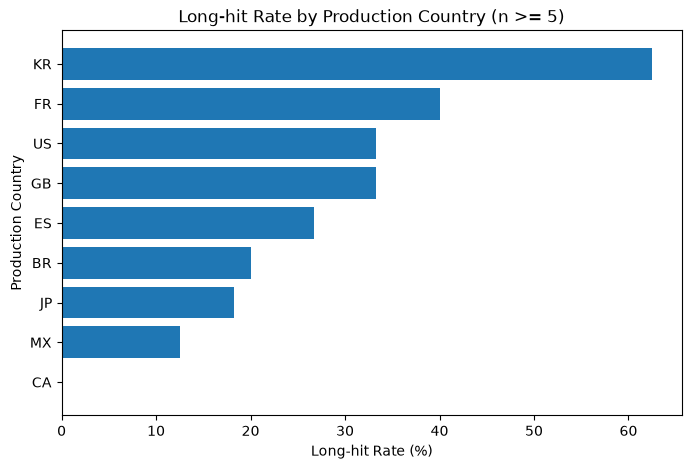

In [35]:
# 표본 5개 이상 제작국가의 장기흥행 비율을 막대그래프로 시각화

plot_data = country_long_hit_filtered.sort_values(
    "long_hit_rate_pct",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data.index,
    plot_data["long_hit_rate_pct"]
)

plt.xlabel("Long-hit Rate (%)")
plt.ylabel("Production Country")
plt.title("Long-hit Rate by Production Country (n >= 5)")

plt.show()

### 제작국가별 장기흥행 비율

표본 수가 5개 이상인 제작국가를 기준으로 비교한 결과,
한국(KR)이 8개 중 5개 장기흥행으로 62.50%의 가장 높은 비율을 보였다.

프랑스(FR)는 40.00%,
미국(US)과 영국(GB)은 각각 33.33%,
스페인(ES)은 26.67%로 나타났다.

브라질(BR)은 20.00%, 일본(JP)은 18.18%,
멕시코(MX)는 12.50%였으며,
캐나다(CA)에서는 이번 표본 내 장기흥행 사례가 확인되지 않았다.

다만 하나의 콘텐츠가 복수의 제작국가를 가질 수 있어
동일 작품이 여러 국가에 중복 포함될 수 있다.

또한 한국 제작 콘텐츠의 표본 수가 8개로 적기 때문에
제작국가 자체의 효과로 일반화하기보다는 탐색적 경향으로 해석한다.

In [36]:
# 장기흥행 여부에 따라 TMDB 평점과 투표 수의 평균·중앙값을 비교

vote_summary = (
    merged_df.groupby("long_hit")
    [["vote_average", "vote_count"]]
    .agg(["mean", "median"])
)

vote_summary

vote_average           vote_count        
                 mean  median         mean  median
long_hit                                          
0            7.380235  7.5320  2294.426087   415.0
1            7.786159  7.9465  3456.977273  1208.0

<Figure size 600x400 with 0 Axes>

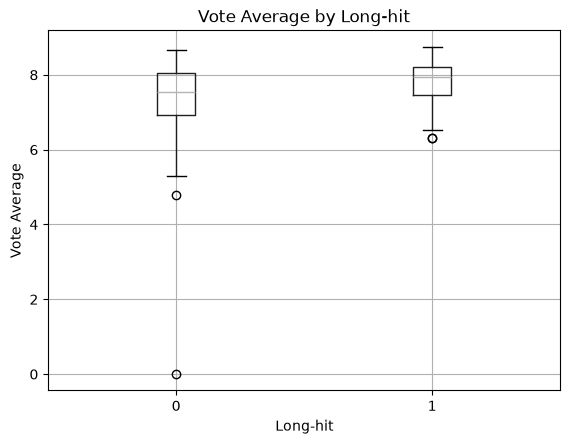

In [37]:
# 장기흥행 여부별 vote_average 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="vote_average",
    by="long_hit"
)

plt.title("Vote Average by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Vote Average")

plt.show()

### TMDB 평점 및 투표 수와 장기흥행

장기흥행 그룹의 TMDB 평균 평점은 7.79,
중앙값은 7.95로 나타났다.

비장기흥행 그룹은 평균 7.38,
중앙값 7.53으로 장기흥행 그룹이 전반적으로 조금 더 높은 평점을 보였다.

투표 수에서도 차이가 확인되었다.
비장기흥행 그룹의 vote_count 중앙값은 415건인 반면,
장기흥행 그룹은 1,208건으로 더 높게 나타났다.

이는 장기흥행 콘텐츠가 더 많은 사용자 평가와 관심을 확보한 경향이 있음을 보여준다.

다만 TMDB의 평점과 vote_count는 현재 누적된 값이므로,
장기흥행의 원인이라기보다 흥행 이후 형성된 관심도와 함께 증가한
사후적 인기 지표일 가능성도 고려해야 한다.

<Figure size 600x400 with 0 Axes>

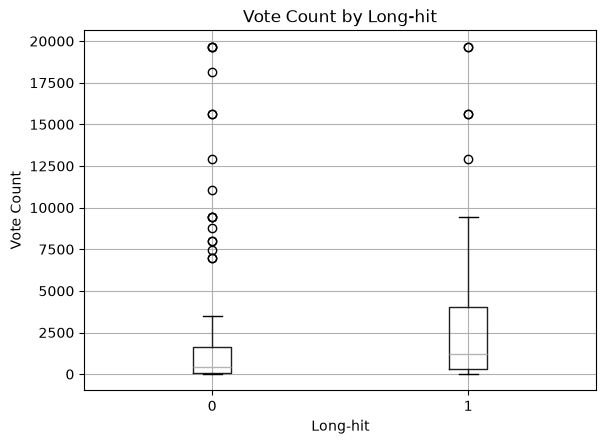

In [38]:
# 장기흥행 여부별 vote_count 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="vote_count",
    by="long_hit"
)

plt.title("Vote Count by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Vote Count")

plt.show()

<Figure size 600x400 with 0 Axes>

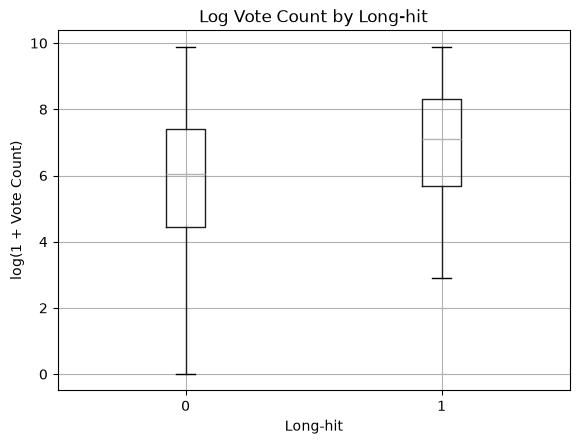

In [39]:
# vote_count의 큰 값 차이를 완화하기 위해 log1p 변환 후 장기흥행 여부별 분포를 비교

merged_df["log_vote_count"] = np.log1p(
    merged_df["vote_count"]
)

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="log_vote_count",
    by="long_hit"
)

plt.title("Log Vote Count by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("log(1 + Vote Count)")

plt.show()

### vote_count 로그 변환 비교

vote_count는 일부 작품의 투표 수가 매우 커
분포가 오른쪽으로 크게 치우쳐 있었다.

따라서 `log1p(vote_count)`로 로그 변환한 뒤
장기흥행 여부별 분포를 다시 비교했다.

로그 변환 후에도 장기흥행 그룹의 분포와 중앙값이
비장기흥행 그룹보다 전반적으로 높게 나타났다.

즉 극단적인 인기 작품의 영향을 줄여서 비교해도
장기흥행 콘텐츠가 상대적으로 더 많은 사용자 반응을 확보한 경향은 유지되었다.

다만 vote_count는 흥행의 결과로 증가했을 가능성이 있으므로
장기흥행을 발생시키는 원인 변수로 단정하지 않는다.

In [40]:
# 장기흥행 여부에 따라 시즌 수와 에피소드 수의 평균·중앙값을 비교

season_episode_summary = (
    merged_df.groupby("long_hit")
    [["number_of_seasons", "number_of_episodes"]]
    .agg(["mean", "median"])
)

season_episode_summary

number_of_seasons        number_of_episodes       
                      mean median               mean median
long_hit                                                   
0                 4.096491    3.0          68.377193   29.0
1                 3.704545    3.0          70.318182   50.0

<Figure size 600x400 with 0 Axes>

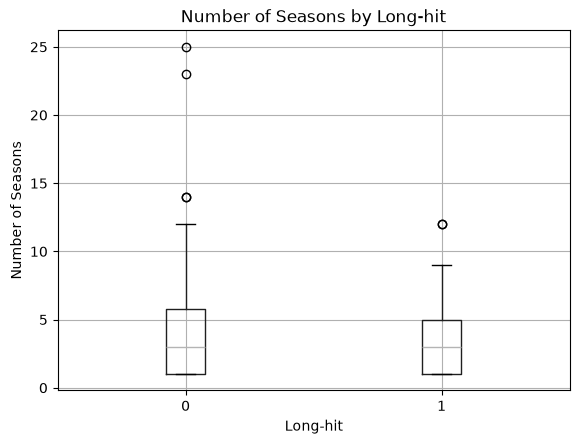

In [41]:
# 장기흥행 여부별 시즌 수 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="number_of_seasons",
    by="long_hit"
)

plt.title("Number of Seasons by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Number of Seasons")

plt.show()

<Figure size 600x400 with 0 Axes>

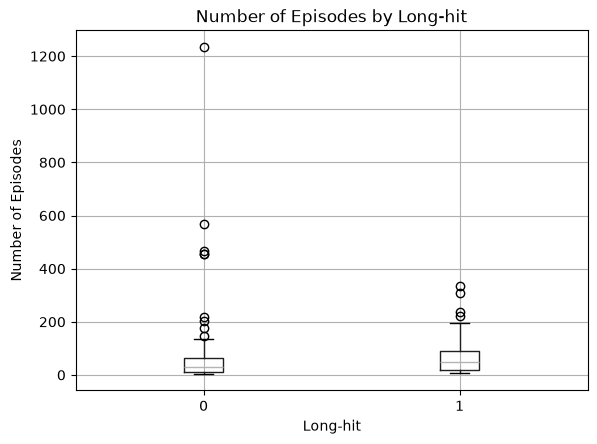

In [42]:
# 장기흥행 여부별 에피소드 수 분포를 박스플롯으로 비교

plt.figure(figsize=(6, 4))

merged_df.boxplot(
    column="number_of_episodes",
    by="long_hit"
)

plt.title("Number of Episodes by Long-hit")
plt.suptitle("")
plt.xlabel("Long-hit")
plt.ylabel("Number of Episodes")

plt.show()

### 시즌 수와 에피소드 수

장기흥행 여부에 따라 시즌 수를 비교한 결과,
두 그룹의 중앙값은 모두 3으로 동일했다.

평균 시즌 수는 비장기흥행 그룹이 4.1,
장기흥행 그룹이 3.7로 오히려 비장기흥행 그룹에서 조금 더 높게 나타났다.

이는 시즌 수가 많다는 사실만으로 장기흥행 여부를 설명하기 어렵다는 것을 보여준다.

에피소드 수의 경우 평균값은
비장기흥행 그룹 68.38편,
장기흥행 그룹 70.32편으로 큰 차이가 없었다.

반면 중앙값은 비장기흥행 그룹 29편,
장기흥행 그룹 50편으로 장기흥행 그룹이 더 높게 나타났다.

다만 비장기흥행 그룹에는 1,000편이 넘는 일부 장수 콘텐츠와 같은 극단값이 존재하므로,
평균값보다는 중앙값과 전체 분포를 함께 보는 것이 적절하다.

또한 TMDB의 시즌 수와 에피소드 수는 현재 시점의 누적 정보이므로,
Netflix Top 10 관측 당시의 시즌·에피소드 구성과 동일하다고 볼 수 없다는 한계가 있다.

In [43]:
# 보정된 merged_df를 기준으로 장르·언어·제작국가와 주요 TMDB 지표의 최종 요약값을 한 번에 확인

# 1. 장르별 long_hit 비율
genre_final = (
    merged_df.assign(
        genre=merged_df["genres"].str.split(", ")
    )
    .explode("genre")
    .groupby("genre")["long_hit"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "content_count",
        "sum": "long_hit_count",
        "mean": "long_hit_rate"
    })
)

genre_final["long_hit_rate"] = genre_final["long_hit_rate"] * 100
genre_final = genre_final[
    genre_final["content_count"] >= 10
].sort_values("long_hit_rate", ascending=False)


# 2. 원어별 long_hit 비율
language_final = (
    merged_df.groupby("original_language")["long_hit"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "content_count",
        "sum": "long_hit_count",
        "mean": "long_hit_rate"
    })
)

language_final["long_hit_rate"] = language_final["long_hit_rate"] * 100
language_final = language_final[
    language_final["content_count"] >= 5
].sort_values("long_hit_rate", ascending=False)


# 3. 제작국가별 long_hit 비율
country_final = (
    merged_df.dropna(subset=["production_countries"])
    .assign(
        production_country=merged_df["production_countries"].str.split(", ")
    )
    .explode("production_country")
    .groupby("production_country")["long_hit"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "content_count",
        "sum": "long_hit_count",
        "mean": "long_hit_rate"
    })
)

country_final["long_hit_rate"] = country_final["long_hit_rate"] * 100
country_final = country_final[
    country_final["content_count"] >= 5
].sort_values("long_hit_rate", ascending=False)


# 4. long_hit 여부별 TMDB 주요 지표 요약
tmdb_metrics_final = (
    merged_df.groupby("long_hit")[
        [
            "vote_average",
            "vote_count",
            "number_of_seasons",
            "number_of_episodes",
            "popularity"
        ]
    ]
    .agg(["mean", "median"])
    .round(2)
)


print("=== 장르별 long_hit 비율 (n >= 10) ===")
display(genre_final.round(2))

print("\n=== 원어별 long_hit 비율 (n >= 5) ===")
display(language_final.round(2))

print("\n=== 제작국가별 long_hit 비율 (n >= 5) ===")
display(country_final.round(2))

print("\n=== long_hit 여부별 TMDB 주요 지표 ===")
display(tmdb_metrics_final)

=== 장르별 long_hit 비율 (n >= 10) ===


,genre,content_count,long_hit_count,long_hit_rate
8,Mystery,30,14,46.67
3,Crime,42,17,40.48
5,Drama,89,33,37.08
0,Action & Adventure,29,6,20.69
10,Sci-Fi & Fantasy,37,7,18.92
2,Comedy,43,8,18.60
1,Animation,26,4,15.38
7,Kids,13,2,15.38
6,Family,12,1,8.33
4,Documentary,11,0,0.00



=== 원어별 long_hit 비율 (n >= 5) ===


,original_language,content_count,long_hit_count,long_hit_rate
9,ko,8,5,62.50
4,es,26,9,34.62
3,en,89,25,28.09
8,ja,11,2,18.18
5,fr,6,1,16.67
12,pt,6,1,16.67



=== 제작국가별 long_hit 비율 (n >= 5) ===


,production_country,content_count,long_hit_count,long_hit_rate
15,KR,8,5,62.50
8,FR,5,2,40.00
23,US,78,26,33.33
9,GB,9,3,33.33
7,ES,15,4,26.67
2,BR,5,1,20.00
14,JP,11,2,18.18
16,MX,8,1,12.50
3,CA,5,0,0.00



=== long_hit 여부별 TMDB 주요 지표 ===


vote_average        vote_count         number_of_seasons         \
                 mean median       mean  median              mean median   
long_hit                                                                   
0                7.38   7.53    2294.43   415.0               4.1    3.0   
1                7.79   7.95    3456.98  1208.0               3.7    3.0   

         number_of_episodes        popularity         
                       mean median       mean median  
long_hit                                              
0                     68.38   29.0      26.11   8.75  
1                     70.32   50.0      34.32  22.63

보정된 TMDB 메타데이터를 기준으로 분석한 결과, Mystery·Crime·Drama 장르에서 상대적으로 높은 장기흥행 비율이 관찰되었다. 
한국어 및 한국 제작 콘텐츠 역시 높은 비율을 보였으나 표본 수가 적어 일반화에는 주의가 필요하다. 
장기흥행 그룹은 TMDB 평점, 투표 수, popularity가 전반적으로 높았지만, 이 지표들은 현재 누적값이므로 흥행의 원인보다는 사후 관심도와의 연관성으로 해석하는 것이 적절하다. 
시즌 수 자체는 두 그룹 간 차이가 크지 않았으며, 에피소드 수는 장기흥행 그룹의 중앙값이 더 높았지만 일부 장수 시리즈의 극단값 영향을 함께 고려해야 한다.

### TMDB 매칭 검증 및 보정

Netflix 관측 종료일인 `2022-01-16`보다 TMDB의 `first_air_date`가 늦게 나타나는 작품을 확인한 결과,
9개 행에서 7개 작품이 검토 대상으로 확인되었다.

TMDB Search API를 이용해 제목뿐 아니라 원제, 원어, 제작국가, 최초 공개일을 함께 비교했고,
이 중 6개 작품이 동명작 또는 다른 작품으로 잘못 매칭된 것으로 판단되어 메타데이터를 보정했다.

보정 대상은 다음과 같다.

- CoComelon
- Love Never Lies
- Newly Rich, Newly Poor
- The Chair
- The Club
- The Seven Deadly Sins

특히 `The Club`은 영문 제목 검색만으로는 멕시코 동명 작품이 후보로 선택되었으나,
터키 원제 `Kulüp`을 추가 확인해 TMDB ID 136125의 실제 작품으로 수정했다.

`The Snitch Cartel: Origins`는 TMDB ID 자체는 유효한 것으로 판단했으나,
TMDB의 `first_air_date`가 Netflix 관측 종료일 이후로 기록되어 있어 날짜 기준 예외로 유지했다.

따라서 이후 2차 EDA는 보정된 TMDB 메타데이터를 기준으로 다시 계산하였다.

## 2차 EDA 핵심 인사이트

1. **장르**
   - Mystery, Crime, Drama가 상대적으로 높은 장기흥행 비율을 보였다.
   - Animation 전체의 장기흥행 비율은 15.38%로 높지 않았지만,
     일부 장기흥행 작품에서는 Action & Adventure, Sci-Fi & Fantasy 등의 장르 조합이 확인되었다.

2. **언어 및 제작국가**
   - 한국어와 한국 제작 콘텐츠에서 높은 장기흥행 비율이 관찰되었다.
   - 다만 표본 수가 적기 때문에 해당 결과를 일반화하기보다는 탐색적 경향으로 해석한다.

3. **평점과 사용자 반응**
   - 장기흥행 그룹은 TMDB 평점과 vote_count가 전반적으로 더 높았다.
   - 다만 현재 누적 지표이므로 장기흥행의 원인보다는 흥행 이후의 관심도와 관련된 지표일 수 있다.

4. **시즌·에피소드 구조**
   - 시즌 수 중앙값은 장기흥행 여부와 관계없이 동일해 시즌 수 자체만으로는 장기흥행을 설명하기 어려웠다.
   - 에피소드 수 중앙값은 장기흥행 그룹에서 더 높았지만,
     극단값과 현재 누적 시즌 정보를 함께 고려해야 한다.

5. **종합**
   - 장기흥행은 하나의 콘텐츠 특성만으로 설명하기 어렵다.
   - 장르·언어·제작국가 같은 콘텐츠 특성과
     초기 시청 성과 및 국가 확산 범위를 함께 고려하는 것이 필요하다.

### 다음 단계

2021~2022년 Netflix 데이터에서 확인한 패턴이 최근 콘텐츠 시장에서도 유지되는지 확인하기 위해,
최신 Netflix 공개 자료와 타 플랫폼의 게임 IP 기반 콘텐츠 사례를 별도의 검증 단계에서 비교한다.